<a href="https://colab.research.google.com/github/Shashank-sketchAl/ML-90-Day-Challenge-/blob/main/Day8_Breast_Cancer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
print(data.target_names)

print("Target values:")
print(df['target'].value_counts())

['malignant' 'benign']
Target values:
target
1    357
0    212
Name: count, dtype: int64


In [3]:
df.shape

(569, 31)

In [4]:
df.isnull().sum().sum()

np.int64(0)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
X = df.drop('target', axis=1)
y = df['target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled , y_train)

LogisticRegression(max_iter=1000)

In [10]:
y_pred = model.predict(X_test_scaled)
print(y_pred[:20])

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


In [13]:
y_prob = model.predict_proba(X_test_scaled)

print(y_prob[:5])

[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


In [16]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

In [17]:
print("y_pred:")
print(y_pred[:10])

print("\ny_prob:")
print(y_prob[:5])

y_pred:
[0 1 0 1 0 1 1 0 0 0]

y_prob:
[[9.99999941e-01 5.88824186e-08]
 [1.13351672e-05 9.99988665e-01]
 [9.93589175e-01 6.41082462e-03]
 [4.66491463e-01 5.33508537e-01]
 [9.99999999e-01 6.52500097e-10]]


In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob[:, 1])

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
ROC-AUC  : 0.9953703703703703


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[41  1]
 [ 1 71]]


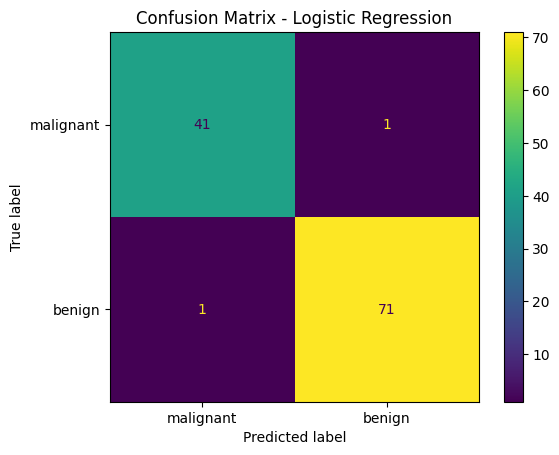

In [23]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels = data.target_names
)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred,target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [27]:
coefficients = pd.Series(model.coef_[0], index = X.columns).sort_values()

print(coefficients)

worst texture             -1.255088
radius error              -1.082965
worst concave points      -0.953686
worst area                -0.947756
worst radius              -0.947616
worst symmetry            -0.939181
area error                -0.929104
worst concavity           -0.823151
worst perimeter           -0.763220
worst smoothness          -0.746625
mean concave points       -0.704156
mean concavity            -0.602103
mean texture              -0.552698
perimeter error           -0.544333
mean area                 -0.541059
mean radius               -0.511479
mean perimeter            -0.476298
concave points error      -0.443784
mean smoothness           -0.212479
worst fractal dimension   -0.187251
mean symmetry             -0.167233
smoothness error          -0.160276
worst compactness          0.055514
concavity error            0.160563
mean fractal dimension     0.199732
texture error              0.248823
symmetry error             0.360492
fractal dimension error    0

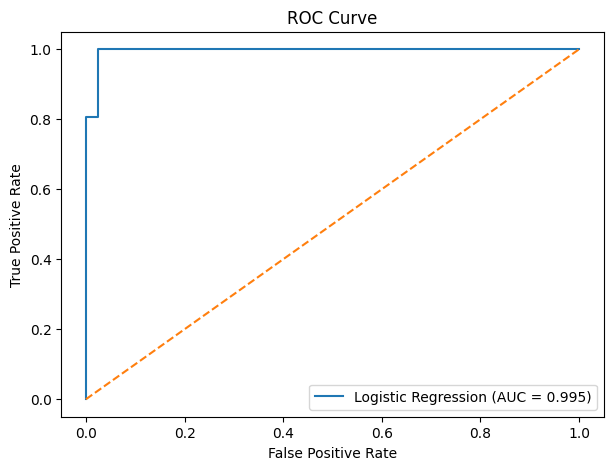

In [28]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

Conclusion: Logistic Regression was successfully implemented for binary classification on the Breast Cancer Wisconsin dataset. The data was divided into training and testing sets and standardized before model training. The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and classification report. The results demonstrate that Logistic Regression can effectively distinguish between the two classes while also providing probability estimates for its predictions.